In [31]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import umap

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

FEATURES = ['VAR_STD', 'Range', 'Energy', 'Peak_to_Peak', 'VAR', 'Max', 'MNF', 'SSC']
N_CHANNELS = 8
signal_cols = [f'Channel {ch}_{feat}' for ch in range(1, N_CHANNELS + 1) for feat in FEATURES]


In [6]:
ruta1='../data/master/intact_boxcox_fused.csv'

In [3]:
ruta2='../data/master/intact_boxcox_normalized.csv'

In [4]:
ruta3='../data/master/intact_boxcox_best_channels.csv'

In [41]:
df_fused = pd.read_csv(ruta1)
df_norm = pd.read_csv(ruta2)
df_best_channels = pd.read_csv(ruta3)

In [24]:
def plot_pca_separability(df, cols, title, hue_col='stimulus', palette='tab10'):
    """
    Aplica PCA a un conjunto de columnas y visualiza la separabilidad 
    de las clases en un espacio 2D.
    """
    # 1. Preparar copia y limpiar NaNs
    df_plot = df.copy()
    X = df_plot[cols].values
    X = np.nan_to_num(X, nan=0.0)

    # 2. Aplicar PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Añadir coordenadas al dataframe temporal
    df_plot['pca_1'] = X_pca[:, 0]
    df_plot['pca_2'] = X_pca[:, 1]

    # 3. Visualización
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_plot, 
        x='pca_1', 
        y='pca_2', 
        hue=hue_col, 
        palette=palette, 
        s=80, 
        alpha=0.8, 
        edgecolor='white', 
        linewidth=0.5
    )

    plt.title(f'{title}', 
              fontweight='bold', fontsize=15)
    plt.xlabel(f'PCA Dim 1 ({pca.explained_variance_ratio_[0]:.2%} var)')
    plt.ylabel(f'PCA Dim 2 ({pca.explained_variance_ratio_[1]:.2%} var)')

    plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

In [36]:
def plot_tsne_separability(df, cols, title, hue_col='stimulus', palette='tab10'):
    """
    Aplica t-SNE a un conjunto de columnas y visualiza la separabilidad 
    de las clases en un espacio 2D.
    """
    # 1. Preparar copia y limpiar NaNs
    df_plot = df.copy()
    X = df_plot[cols].values
    X = np.nan_to_num(X, nan=0.0)

    # 2. Aplicar t-SNE
    tsne = TSNE(
        n_components=2, 
        perplexity=min(30, X.shape[0]-1), 
        learning_rate='auto', 
        init='pca', 
        random_state=42
    )
    X_tsne = tsne.fit_transform(X)

    # Añadir coordenadas al dataframe temporal
    df_plot['tsne_1'] = X_tsne[:, 0]
    df_plot['tsne_2'] = X_tsne[:, 1]

    # 3. Visualización
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_plot, 
        x='tsne_1', 
        y='tsne_2', 
        hue=hue_col, 
        palette=palette, 
        s=80, 
        alpha=0.8, 
        edgecolor='white', 
        linewidth=0.5
    )

    plt.title(f'{title}', 
              fontweight='bold', fontsize=15)
    plt.xlabel('t-SNE Dim 1')
    plt.ylabel('t-SNE Dim 2')

    plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

In [26]:
def plot_umap_separability(df, cols, title, hue_col='stimulus', palette='tab10'):
    """
    Aplica UMAP a un conjunto de columnas y visualiza la separabilidad 
    de las clases en un espacio 2D.
    """
    # 1. Preparar copia y limpiar NaNs
    df_plot = df.copy()
    X = df_plot[cols].values
    X = np.nan_to_num(X, nan=0.0)

    # 2. Aplicar UMAP
    # n_neighbors: balance entre estructura local vs global
    # min_dist: control del agrupamiento de puntos
    reducer = umap.UMAP(
        n_neighbors=15, 
        min_dist=0.1, 
        n_components=2, 
        random_state=42
    )
    X_umap = reducer.fit_transform(X)

    # Añadir coordenadas al dataframe temporal
    df_plot['umap_1'] = X_umap[:, 0]
    df_plot['umap_2'] = X_umap[:, 1]

    # 3. Visualización
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_plot, 
        x='umap_1', 
        y='umap_2', 
        hue=hue_col, 
        palette=palette, 
        s=80, 
        alpha=0.8, 
        edgecolor='white', 
        linewidth=0.5
    )

    plt.title(f'{title}', 
              fontweight='bold', fontsize=15)
    plt.xlabel('UMAP Dim 1')
    plt.ylabel('UMAP Dim 2')

    plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

In [37]:
def plot_kpca_separability(df, cols, title, kernel='rbf', hue_col='stimulus', palette='tab10'):
    """
    Aplica Kernel PCA a un conjunto de columnas y visualiza la separabilidad 
    de las clases en un espacio 2D.
    """
    # 1. Preparar copia y limpiar NaNs
    df_plot = df.copy()
    X = df_plot[cols].values
    X = np.nan_to_num(X, nan=0.0)

    # 2. Aplicar Kernel PCA
    # El kernel 'rbf' es el más común para capturar relaciones no lineales
    kpca = KernelPCA(n_components=2, kernel=kernel, fit_inverse_transform=True, random_state=42)
    X_kpca = kpca.fit_transform(X)

    # Añadir coordenadas al dataframe temporal
    df_plot['kpca_1'] = X_kpca[:, 0]
    df_plot['kpca_2'] = X_kpca[:, 1]

    # 3. Visualización
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=df_plot, 
        x='kpca_1', 
        y='kpca_2', 
        hue=hue_col, 
        palette=palette, 
        s=80, 
        alpha=0.8, 
        edgecolor='white', 
        linewidth=0.5
    )

    plt.title(f'{title}', 
              fontweight='bold', fontsize=15)
    plt.xlabel('KPCA Dim 1')
    plt.ylabel('KPCA Dim 2')

    plt.legend(title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

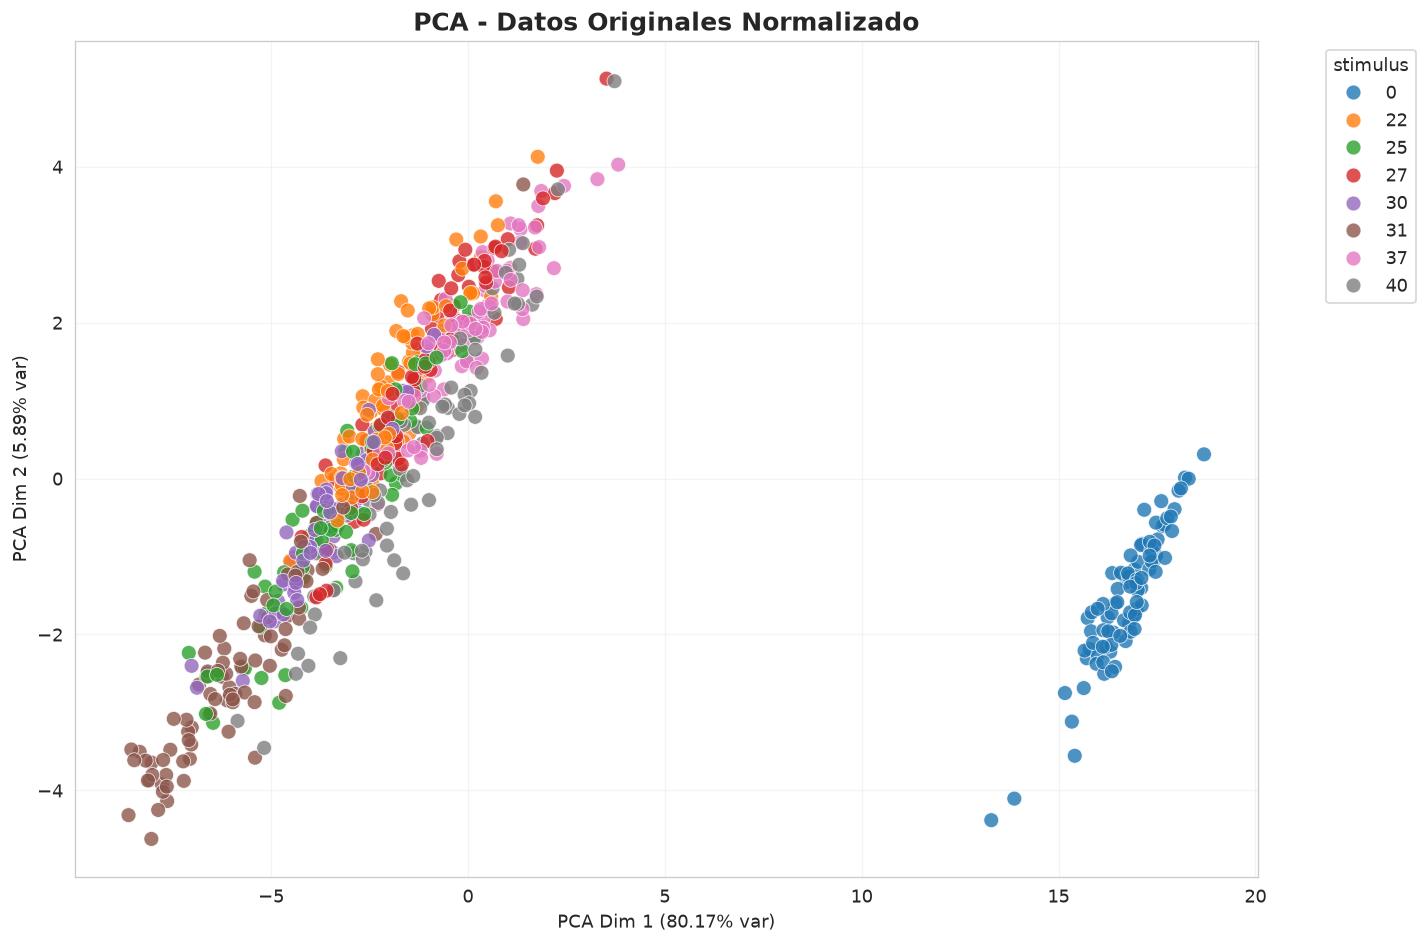

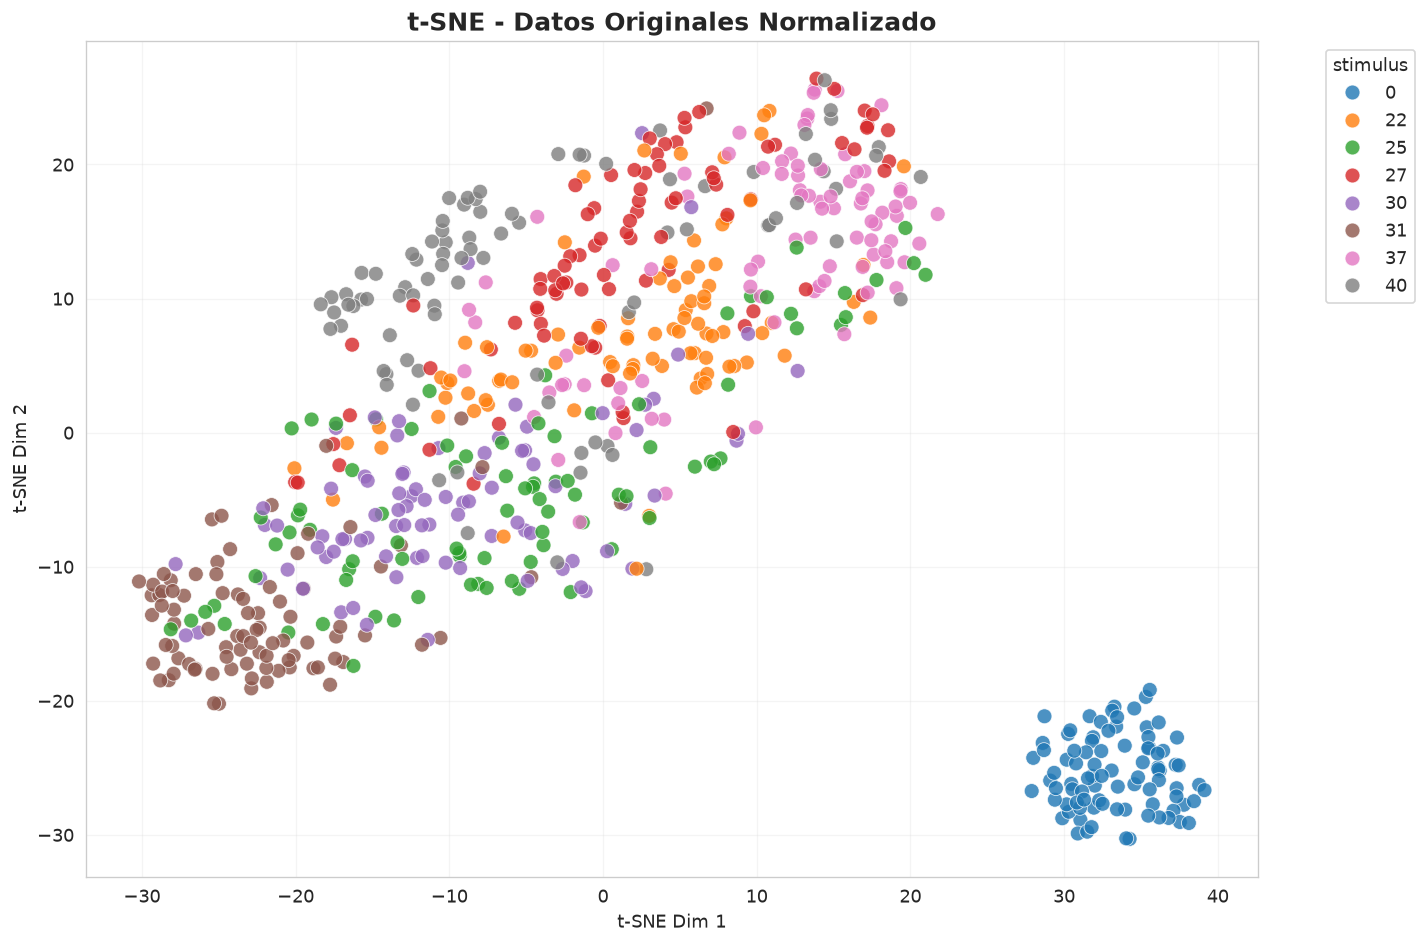

/home/Felixphz/project/sEMG-ArmBand/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


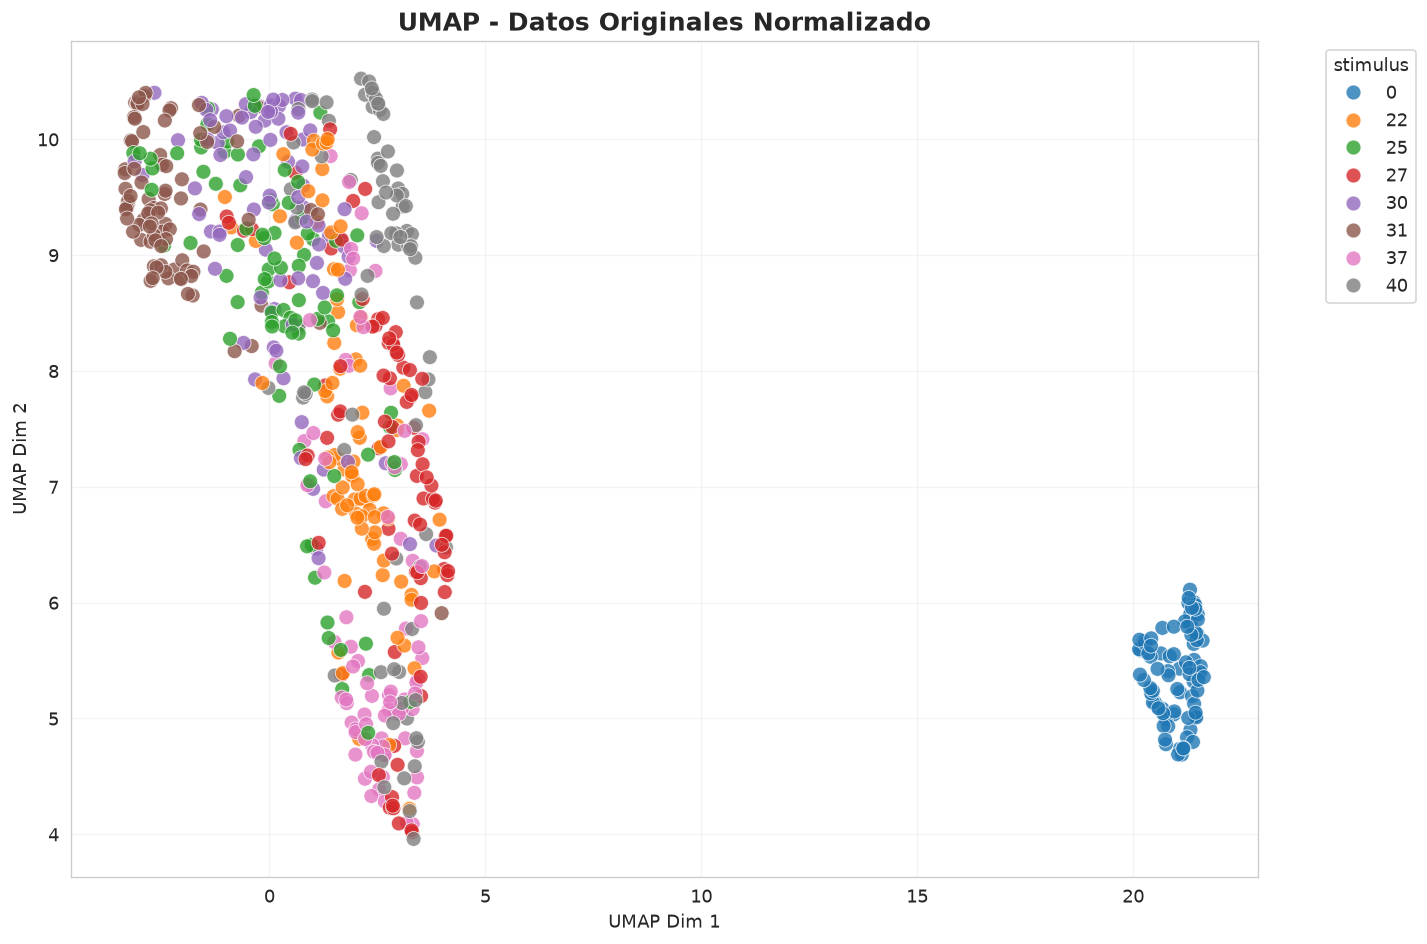

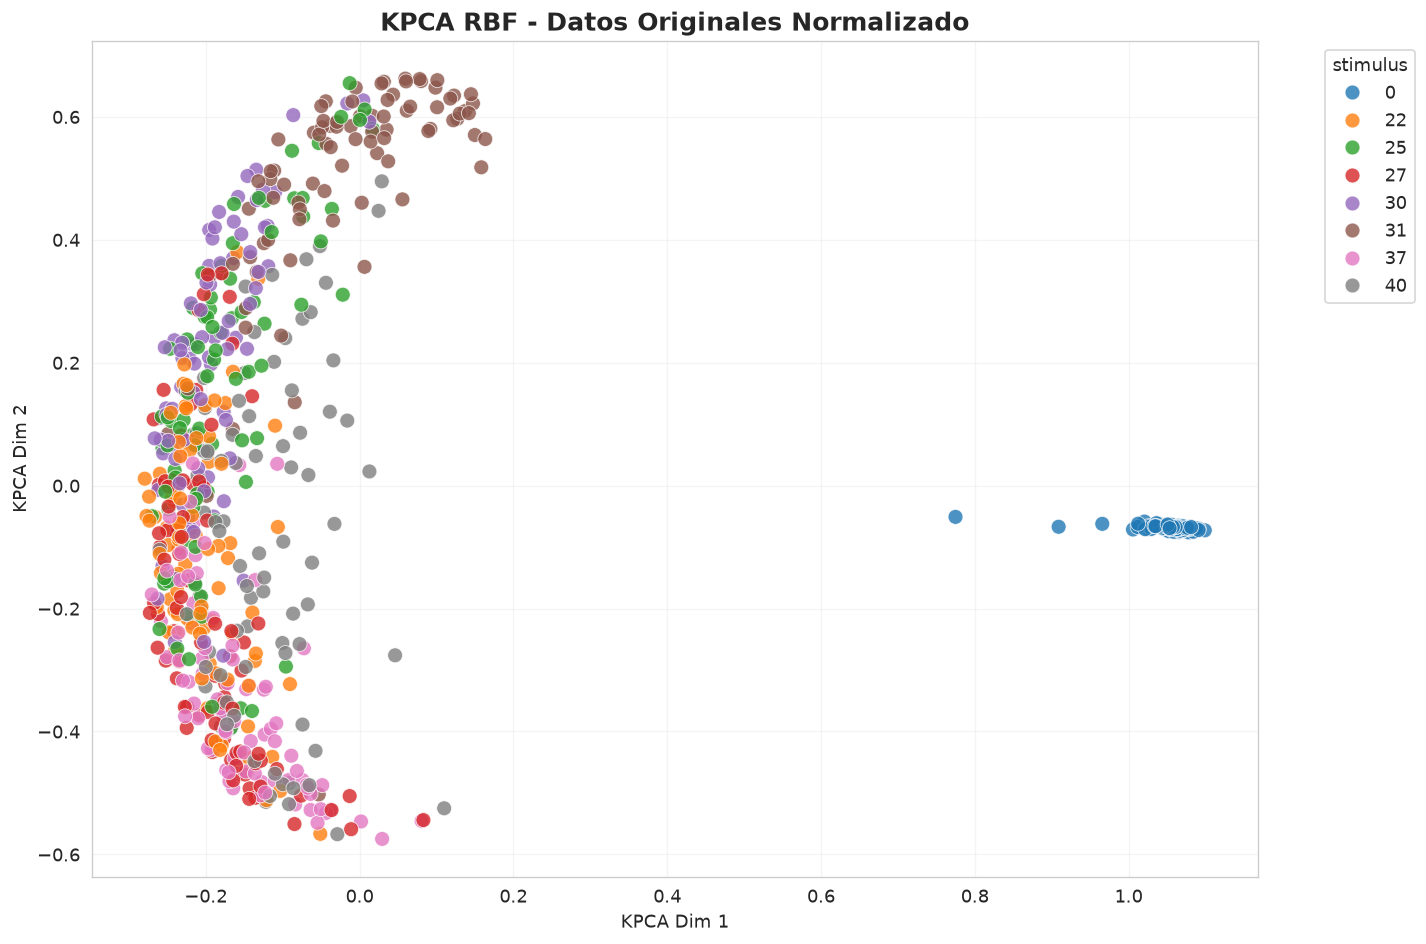

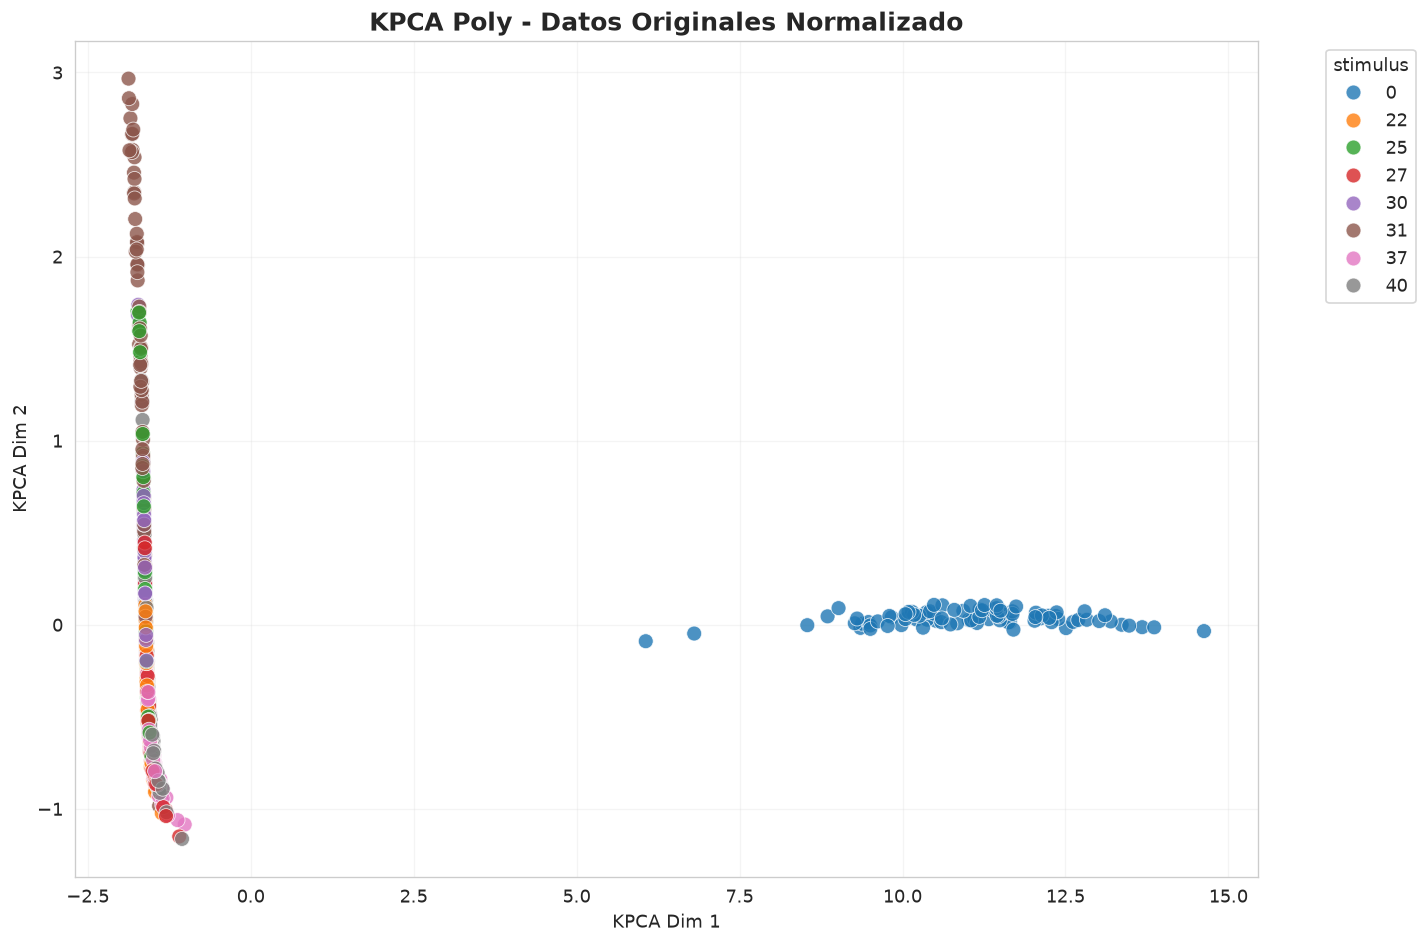

In [40]:
plot_pca_separability(df_norm,signal_cols,"PCA - Datos Originales Normalizado",)
plot_tsne_separability(df_norm, signal_cols, "t-SNE - Datos Originales Normalizado")
plot_umap_separability(df_norm, signal_cols, "UMAP - Datos Originales Normalizado")
# Default RBF kernel
plot_kpca_separability(df_norm, signal_cols, "KPCA RBF - Datos Originales Normalizado")
# You can also try other kernels like 'poly' or 'sigmoid'
plot_kpca_separability(df_norm, signal_cols, "KPCA Poly - Datos Originales Normalizado", kernel='poly')

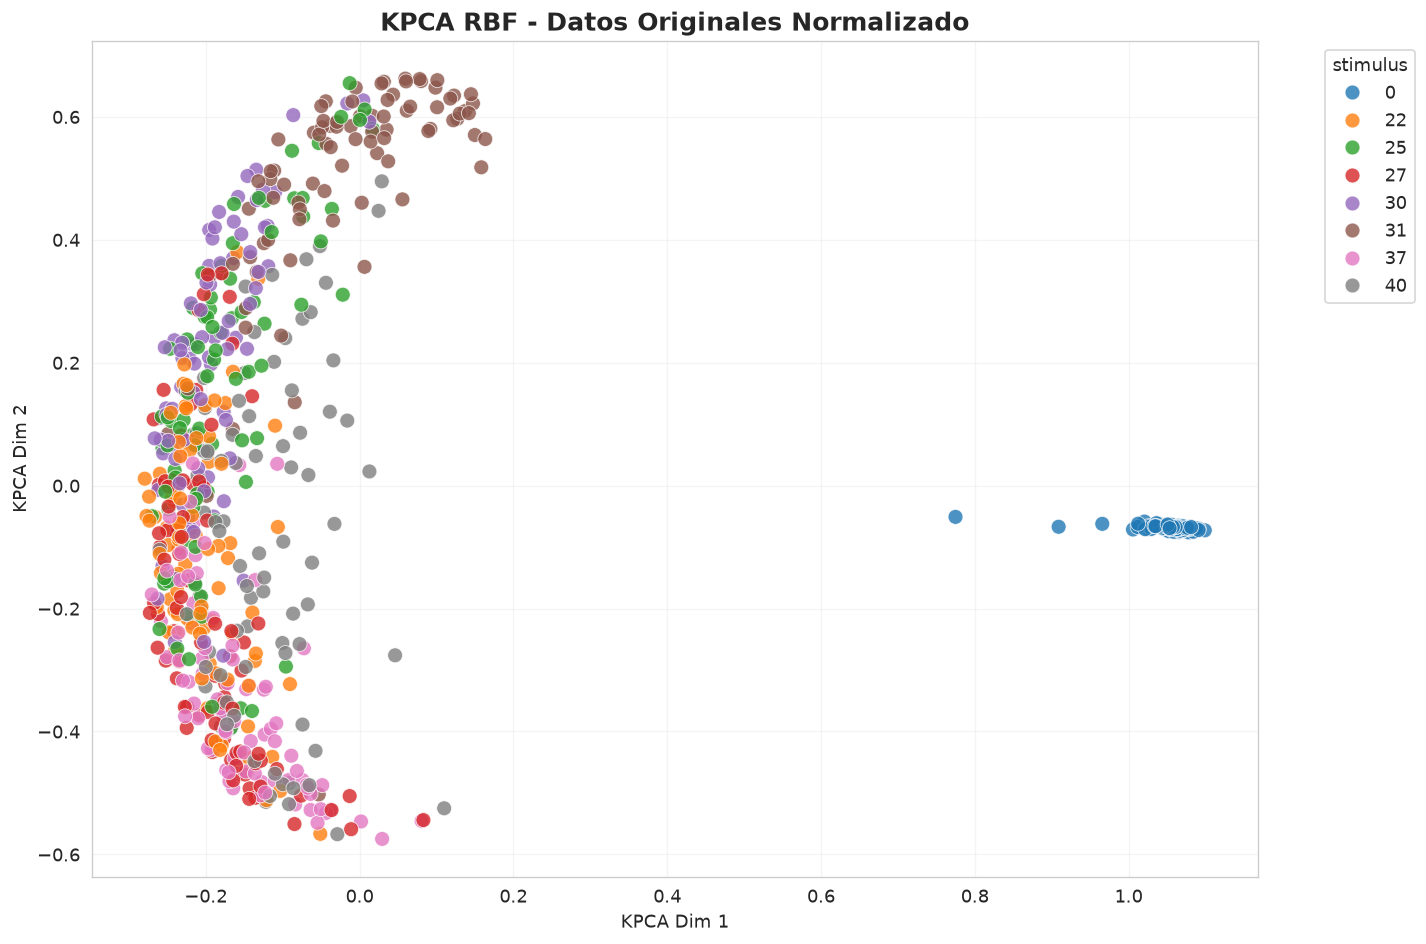

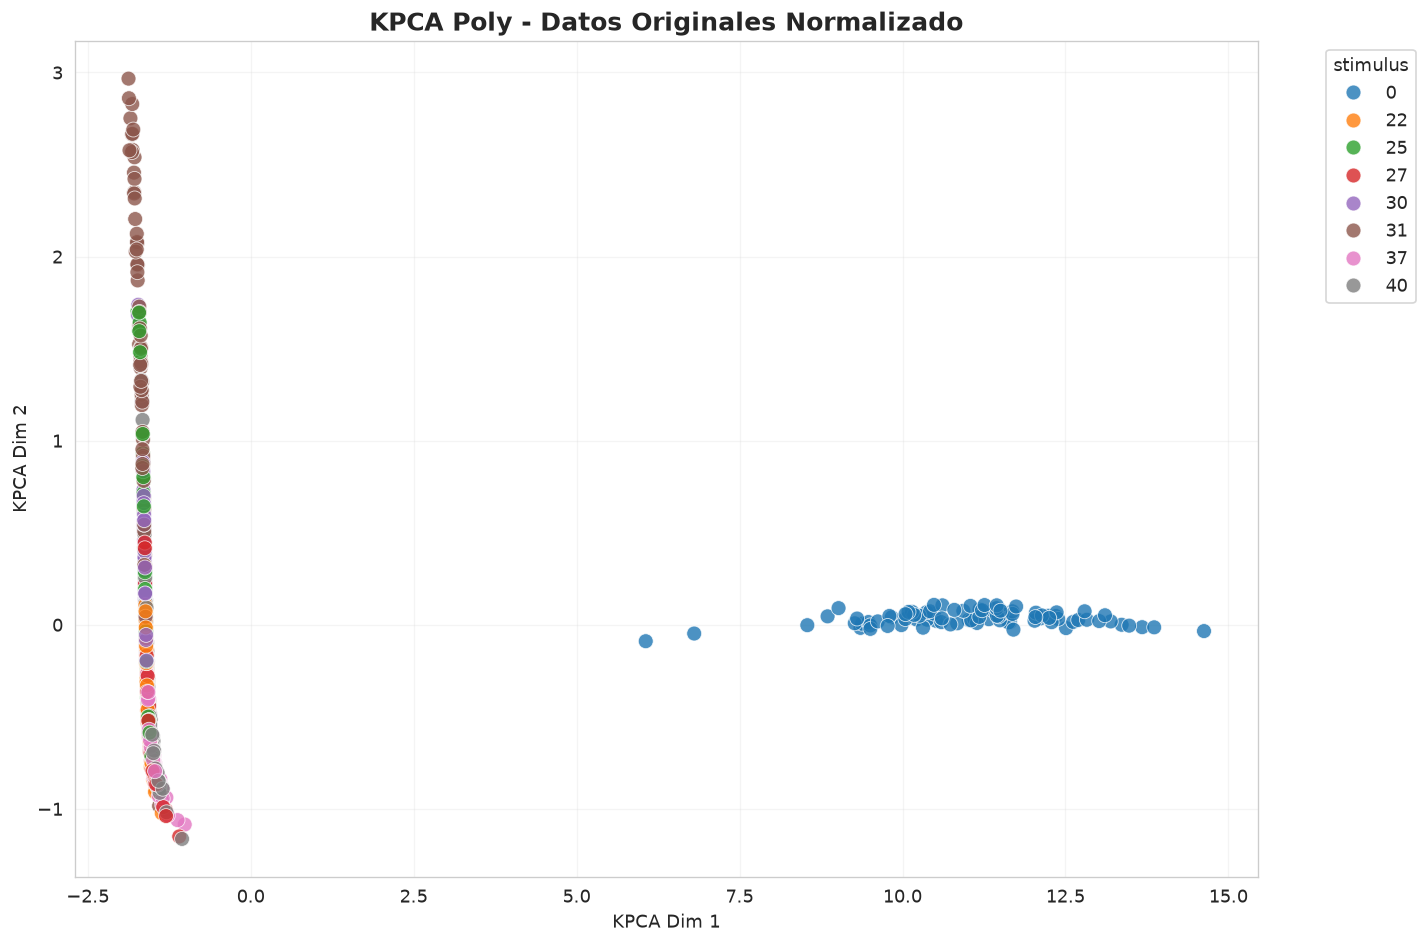

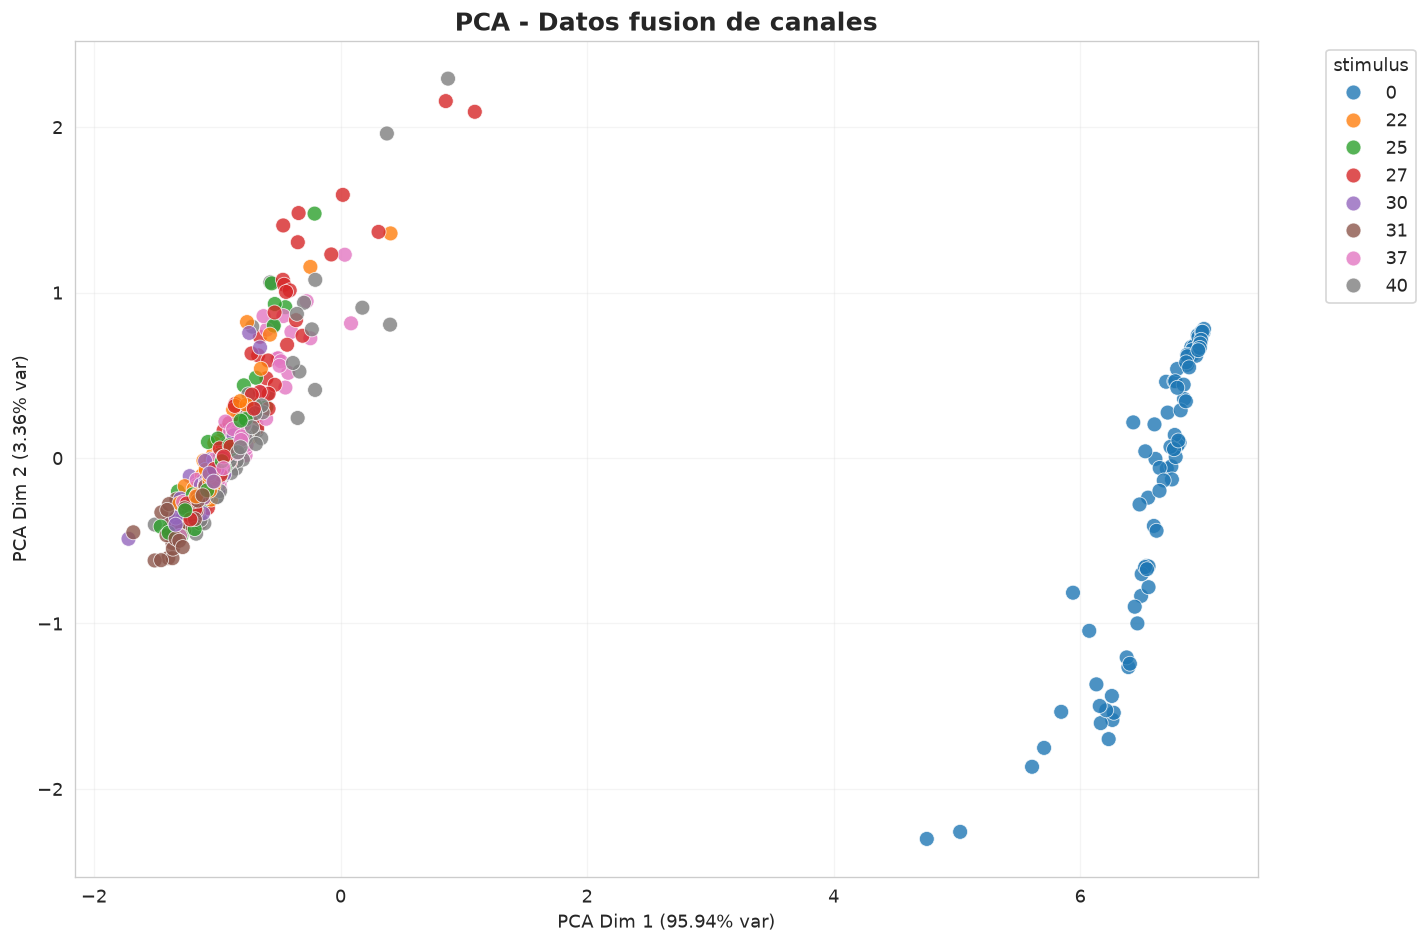

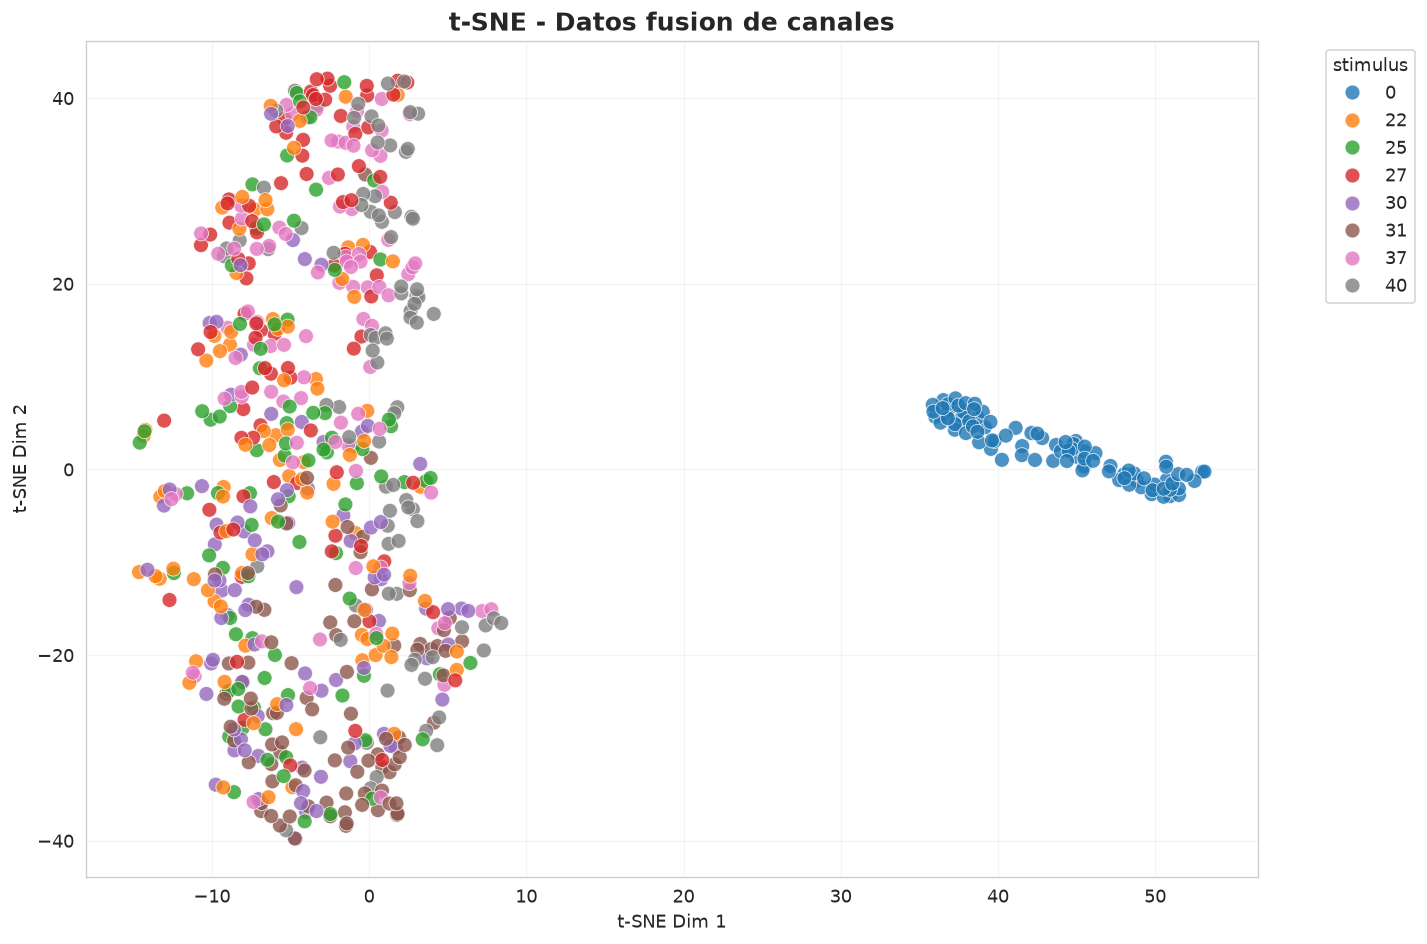

/home/Felixphz/project/sEMG-ArmBand/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


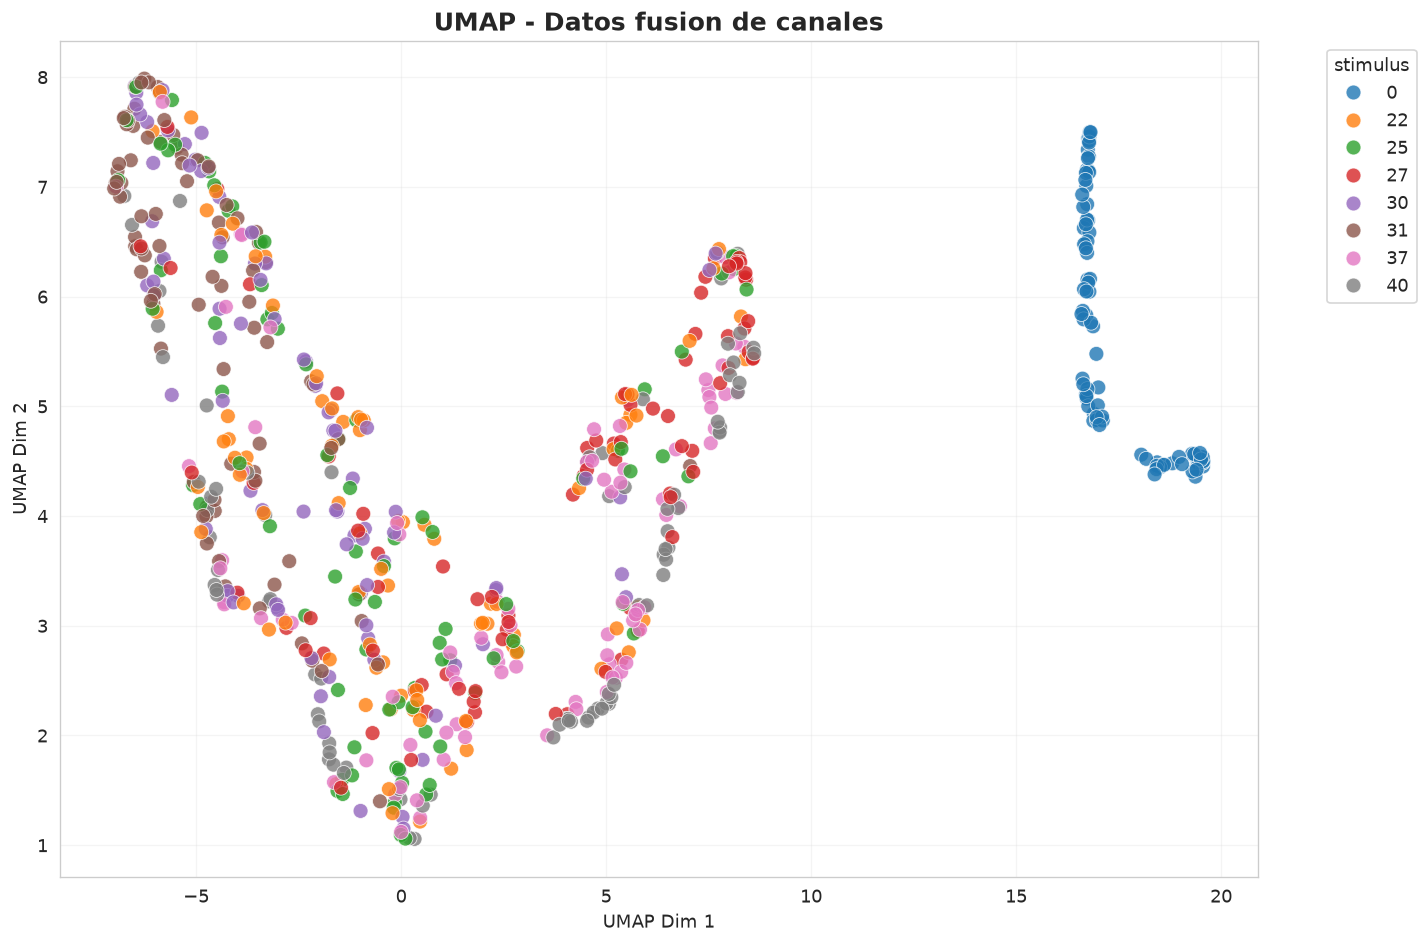

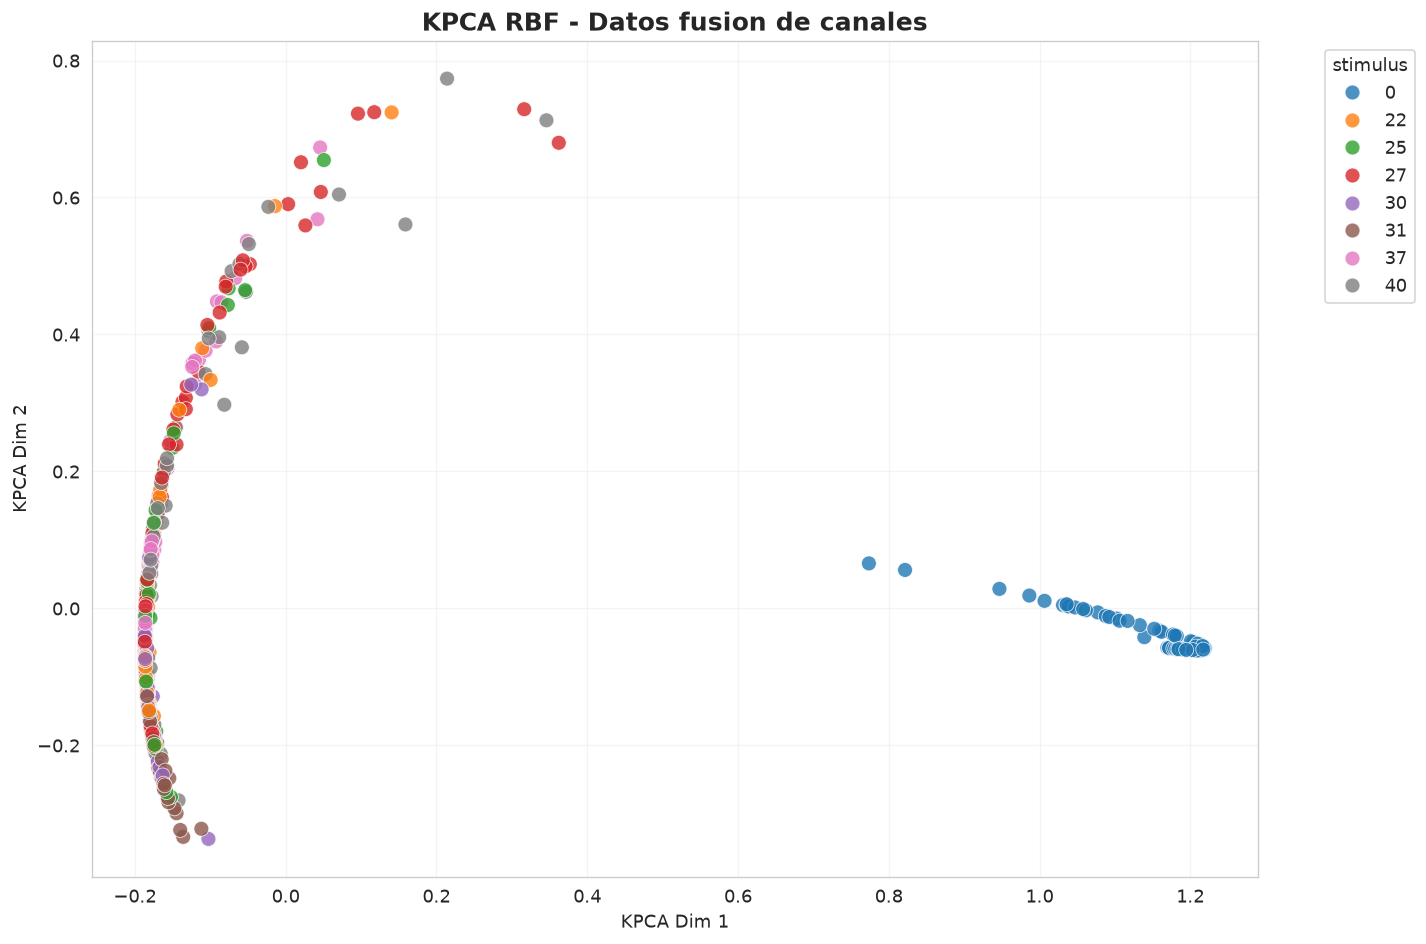

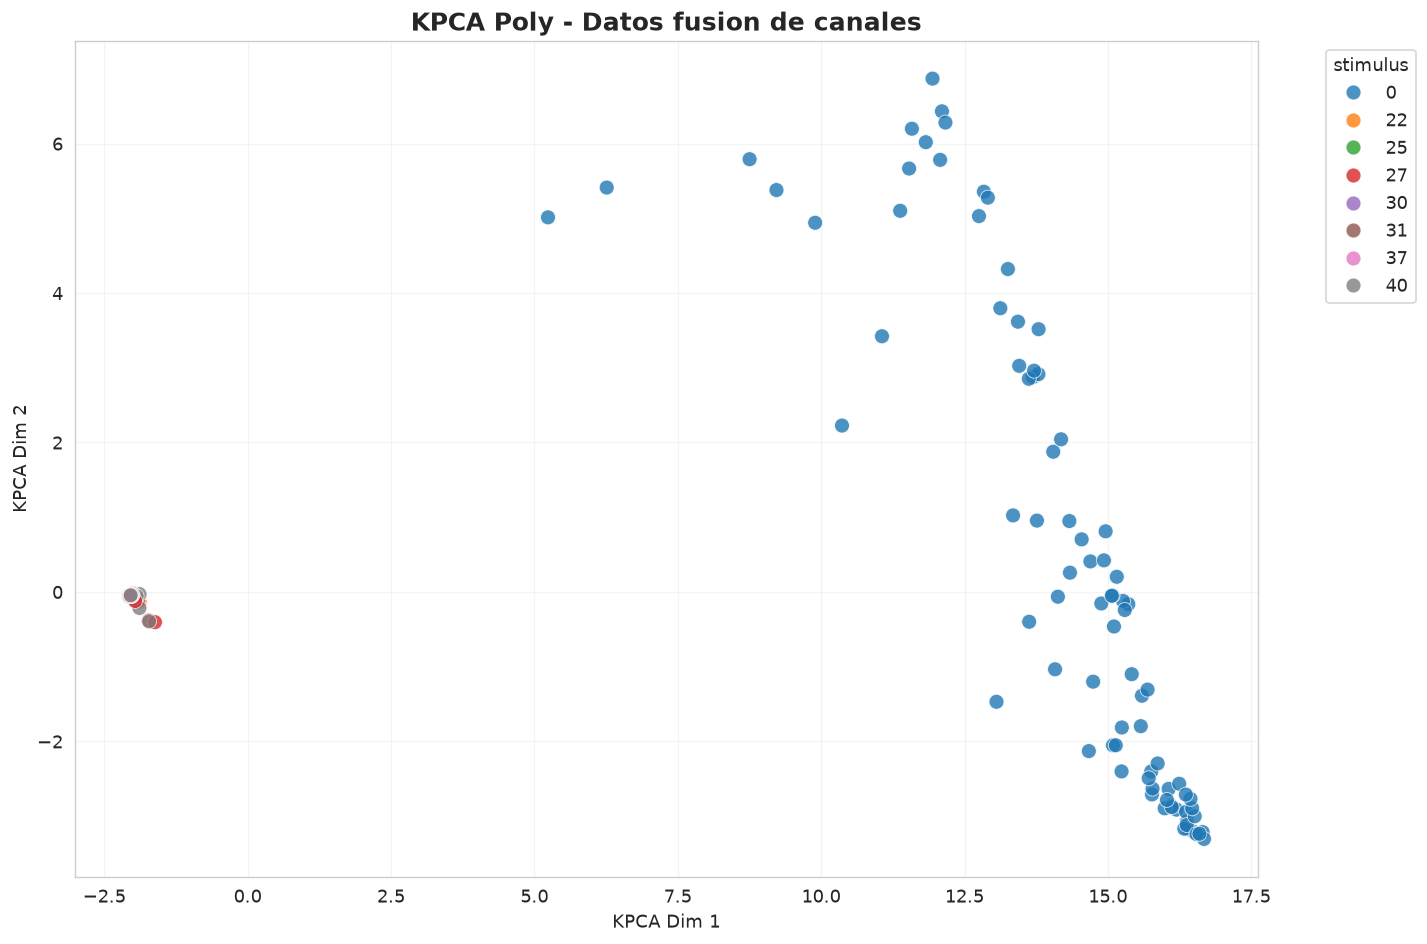

In [42]:
plot_pca_separability(df_fused,FEATURES,"PCA - Datos fusion de canales",)
plot_tsne_separability(df_fused, FEATURES, "t-SNE - Datos fusion de canales")
plot_umap_separability(df_fused, FEATURES, "UMAP - Datos fusion de canales")
# Default RBF kernel
plot_kpca_separability(df_fused, FEATURES, "KPCA RBF - Datos fusion de canales")
# You can also try other kernels like 'poly' or 'sigmoid'
plot_kpca_separability(df_fused, FEATURES, "KPCA Poly - Datos fusion de canales", kernel='poly')